# Anomaly Detection Model for Nairobi Securities Exchange Stocks 

## Table of Contents

#### 1. Problem Statement
#### 2. Objective
#### 3. Environment Setup
#### 4. Exploratory Data Analysis(EDA)
#### 5. Processing
#### 6. Model Selection
#### 7. Modelling
#### 8. Evaluation
#### 9. Prediction

## Problem Statement

Monitoring daily trading activity across all listed securities is essential for maintaining a fair, transparent, and orderly securities market. However, manually identifying unusual trading behaviour from large volumes of market data can be time-consuming and challenging.

This notebook develops an intelligent anomaly detection model using historical trading data from the Nairobi Securities Exchange (NSE). The model is intended to support the NSE's market surveillance function by providing an early warning system that flags securities requiring further investigation.

## Objective

To develop an anomaly detection model that identifies securities exhibiting abnormal trading behaviour using historical daily trading data from the Nairobi Securities Exchange (NSE).

## Environment Setup

### Imports

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Scaling
from sklearn.preprocessing import StandardScaler

# ignore warning
import warnings

# Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_rows", None)

### Data

In [2]:
# Load my data
data = pd.read_csv('/kaggle/input/datasets/mithamomorgan/nse-23-24/Completed_2024_23(oct-dec)_Data.csv')

## EDA

### Overview

In [3]:
# overview
print('#'*60 + ' NSE DATA ' +'#'*60)
display(data.head())

# Shape
print('\n'+ '#'*30 + ' SHAPE ' +'#'*30)
display(data.shape)

# Stock market characteristics
# display(data.columns)

# Nulls
print('\n'+ '#'*30 + ' NULLS ' +'#'*30)
display(data.isna().sum())

# dtypes
print('\n'+ '#'*30 + ' DATA TYPES ' +'#'*30)
display(data.dtypes)

# Duplicates
print('\n'+ '#'*30 + ' DUPLICATES ' +'#'*30)
display(data.duplicated().sum())

# Unique dates
print('\n'+ '#'*30 + ' UNIQUE DATES ' +'#'*30)
display(data["DATE"].nunique())

############################################################ NSE DATA ############################################################


,DATE,52WK HIGH,52WK LOW,SECTOR,COMPANY,ISIN CODE,STATUS,BID,ASK,HIGH,LOW,PREVIOUS PRICE,VOLUME,TOTAL NO OF SHARES ISSUED,MRT CAP,VWAP,10 % up,10% down
0,1/12/2023,14.50,10,AGRICULTURAL,Eaagads Ltd Ord 1.25 AIMS,KE0000000208,NaN,11.8,NaN,12.7,12.7,11.8,"1,900","32,157,000","408,393,900",12.7,13.97,11.43
1,1/12/2023,430.00,240,AGRICULTURAL,Kakuzi Plc Ord.5.00,KE0000000281,NaN,385,406,NaN,NaN,385,-,"19,599,999","7,545,999,615",385,423.5,346.5
2,1/12/2023,249.00,81,AGRICULTURAL,Kapchorua Tea Kenya Plc Ord Ord 5.00AIMS,KE4000001760,cd,230,240,NaN,NaN,239.25,-,"7,824,000","1,871,892,000",239.25,263.18,215.33
3,1/12/2023,490.00,320,AGRICULTURAL,The Limuru Tea Co. Plc Ord 10.00AIMS,KE0000000356,NaN,NaN,NaN,NaN,NaN,380,-,"2,400,000","912,000,000",380,418,342
4,1/12/2023,32.60,18,AGRICULTURAL,Sasini Plc Ord 1.00,KE0000000430,NaN,19.95,20,20,20,18.95,"1,800","228,055,500","4,561,110,000",20,22,18



############################## SHAPE ##############################


(7758, 18)


############################## NULLS ##############################


...

DATE                          object
52WK HIGH                    float64
52WK LOW                      object
SECTOR                        object
COMPANY                       object
 ISIN  CODE                   object
 STATUS                       object
BID                           object
ASK                           object
HIGH                          object
LOW                           object
PREVIOUS PRICE                object
VOLUME                        object
TOTAL NO OF SHARES ISSUED     object
MRT CAP                       object
VWAP                          object
10 % up                       object
 10% down                     object
dtype: object


############################## DUPLICATES ##############################


np.int64(0)


############################## UNIQUE DATES ##############################


118

### Preprocessing

In [4]:
def preprocessing(df):
    # cleaning feature names
    df.columns = (
        data.columns
          .str.lower()
          .str.strip()
          .str.replace(r"[^\w\s]", "", regex=True)
          .str.replace(r"\s+", "_", regex=True)
    )

    # cleaning the numerical columns
    numeric_cols = [
        '52wk_high', '52wk_low', 'bid', 'ask', 'high', 'low',
        'previous_price', 'volume', 'vwap',
        'total_no_of_shares_issued', 'mrt_cap',
        '10_up', '10_down'
    ]

    # Clean company names
    df['company'] = df['company'].str.strip()

    # convert num cols into numeric dtype
    for col in numeric_cols:
        data[col] = (
            data[col]
            .astype(str)
            .str.strip()
            .str.replace(',', '', regex=False)
            .replace({'-': pd.NA, '': pd.NA})
        )
    
        data[col] = pd.to_numeric(data[col], errors='coerce')

    # date future engineering
    df["date"] = pd.to_datetime(df["date"])
    df["year"] = df["date"].dt.year
    
    # fill status nulls with 'ord'
    df["status"] = df["status"].fillna("ord")
    
    # Fill missing 10% trading limits using the previous price
    df['10_up'] = df['10_up'].fillna(df['previous_price'] * 1.10)
    df['10_down'] = df['10_down'].fillna(df['previous_price'] * 0.90)

    # Filling previous price
    df = df.sort_values(["company", "date"]).reset_index(drop=True)
    df["previous_price"] = (df["previous_price"].fillna(df.groupby("company")["vwap"].shift(1)))

    # filling null volumes with zero- No shares traded
    df['volume'] = df['volume'].fillna(0)

    # total_no_of_shares_issued
    df["total_no_of_shares_issued"] = df["total_no_of_shares_issued"].fillna(
        df.groupby(["year", "company"])["total_no_of_shares_issued"].transform("max")
    )

    # special kplc preference securities
    df.loc[
        df['company'] == 'Kenya Power & Lighting Plc 4% Pref 20.00',
        'total_no_of_shares_issued'
    ] = 1800000
    
    df.loc[
        df['company'] == 'Kenya Power & Lighting Plc 7% Pref 20.00',
        'total_no_of_shares_issued'
    ] = 350000

    # market cap = total_no_of_shares_issued * vwap
    df["mrt_cap"] = df["mrt_cap"].fillna(df["total_no_of_shares_issued"] * df["vwap"])

    # convert objects to 'category'
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    df[cat_cols] = df[cat_cols].astype("category")

    # Drop regulatory price limit features- do not add new info
    df = df.drop(columns=["10_up", "10_down"])

    return df

data = preprocessing(data)

### Categories

In [5]:
# status
print('#'*30 + ' STATUS ' +'#'*30)
display(data['status'].value_counts())

# Company
print('\n'+ '#'*30 + ' COMPANY ' +'#'*30)
display(data['company'].nunique())
# data['company'].value_counts()

# Sector
print('\n'+ '#'*30 + ' SECTOR ' +'#'*30)
display(data['sector'].nunique())
display(data['sector'].value_counts())

############################## STATUS ##############################


status
ord    6738
S       482
cd      313
xd      225
Name: count, dtype: int64


############################## COMPANY ##############################


69


############################## SECTOR ##############################


14

sector
COMMERCIAL AND SERVICES         1534
BANKING                         1298
MANUFACTURING & ALLIED           944
ENERGY & PETROLEUM               708
INSURANCE                        708
AGRICULTURAL                     708
INVESTMENT                       590
CONSTRUCTION & ALLIED            590
REAL ESTATE INVESTMENT TRUST     206
AUTOMOBILES & ACCESSORIES        118
INVESTMENT SERVICES              118
EXCHANGE TRADED FUNDS            118
TELECOMMUNICATION                 59
TELECOMMUNICATION                 59
Name: count, dtype: int64

### Numericals

In [6]:
numeric_cols = [
    '52wk_high', '52wk_low', 'bid', 'ask', 'high', 'low',
    'previous_price', 'volume', 'vwap',
    'total_no_of_shares_issued', 'mrt_cap'
]

data[numeric_cols].describe()

,52wk_high,52wk_low,bid,ask,high,low,previous_price,volume,vwap,total_no_of_shares_issued,mrt_cap
count,"7,758.00","7,758.00","6,066.00","6,002.00","5,206.00","5,206.00","7,758.00","7,758.00","7,758.00","7,758.00","7,758.00"
mean,124.16,84.69,74.05,68.19,46.36,45.63,110.50,"205,692.27",110.58,"1,527,771,866.72","22,157,066,010.86"
std,425.10,294.38,284.92,273.81,145.68,144.64,397.63,"1,849,645.95",398.05,"5,024,357,082.93","70,635,881,641.17"
min,0.27,0.16,0.00,0.00,0.17,0.16,0.17,0.00,0.17,"102,272.00","2,100,000.00"
25%,4.20,2.35,2.50,2.80,2.35,2.29,3.24,0.00,3.24,"80,206,616.00","586,574,727.00"
50%,14.00,10.00,12.90,13.60,12.00,11.80,11.60,"1,100.00",11.60,"272,440,473.00","2,809,793,250.00"
75%,43.00,26.50,35.80,37.00,35.10,35.00,35.80,"15,000.00",35.80,"1,128,028,321.00","13,123,099,455.00"
max,"4,900.00","1,880.00","3,000.00","3,600.00","3,065.00","3,065.00","3,065.00","72,111,600.00","3,065.00","40,065,428,000.00","671,095,919,000.00"


## Feature Engineering

In [7]:
# Create relative market behaviour features for anomaly detection- row-wise features.
def feature_engineering(df):

    # Daily Return Feature- percentage price movement
    df["price_return"] = ((df["vwap"] - df["previous_price"]) / df["previous_price"])

    # Volatility Feature- intraday price fluctuation
    df["intraday_range"] = ((df["high"] - df["low"]) / df["previous_price"]).fillna(0)

    # Price Position Features-  how close today's price is to the 52-week extremes?
    df["distance_to_52wk_high"] = ((df["52wk_high"] - df["vwap"]) / df["52wk_high"])

    df["distance_to_52wk_low"] = ((df["vwap"] - df["52wk_low"]) / df["52wk_low"])

    # Liquidity - proportion of outstanding shares traded
    df["turnover_ratio"] = (df["volume"] / df["total_no_of_shares_issued"])

    # Relative bid discount from VWAP
    df["bid_discount"] = ((df["vwap"] - df["bid"]) / df["vwap"]).fillna(0)

    # Relative ask premium above VWAP
    df["ask_premium"] = ((df["ask"] - df["vwap"]) / df["vwap"]).fillna(0)

    # Relative bid-ask spread
    df["relative_spread"] = ((df["ask"] - df["bid"]) / df["vwap"]).fillna(0)

    # Remove raw features after creating the relative features.
    df = df.drop(columns=["52wk_high", "52wk_low", "high", "low", "bid", "ask"])

    return df 

data = feature_engineering(data)

In [8]:
# Create historical features using only past information- Leakage free
def historical_features(df):

    # Ensure proper ordering
    df = df.sort_values(["company", "date"]).copy()

    # Previous 5 trading days average volume
    rolling_volume = (df.groupby("company")["volume"].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()))

    # Avoid division by zero
    df["relative_volume"] = (df["volume"] / rolling_volume.replace(0, np.nan))

    # No historical volume available or zero baseline
    df["relative_volume"] = (df["relative_volume"].fillna(1))

    return df

data = historical_features(data)

/tmp/ipykernel_57/653281113.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rolling_volume = (df.groupby("company")["volume"].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean()))


## Modelling

### Preprocessing

In [9]:
# KEEP ORIGINAL DATA FOR ANALYSIS
results_info = data[
    [
        "date",
        "company",
        "isin_code",
        "sector",
        "status",
        "previous_price",
        "vwap",
        "volume",
        "total_no_of_shares_issued",
        "mrt_cap"
    ]
].copy()


# ENCODE CATEGORICAL VARIABLES
data = pd.get_dummies(
    data,
    columns=["sector", "status"],
    drop_first=False,
    dtype=int
)

# SORT DATA BY TIME
data = data.sort_values("date").reset_index(drop=True)

# DEFINE FEATURES FOR MODEL
exclude_cols = [
    "date",
    "company",
    "isin_code",
    "previous_price",
    "vwap",
    "volume",
    "total_no_of_shares_issued",
    "mrt_cap"
]


feature_cols = [col for col in data.columns if col not in exclude_cols]

# Numerical variables to scale
numeric_features = [
    "price_return",
    "intraday_range",
    "distance_to_52wk_high",
    "distance_to_52wk_low",
    "turnover_ratio",
    "relative_volume",
    "bid_discount",
    "ask_premium",
    "relative_spread"
]

### Train/Test Split

In [10]:
# CREATE EXPANDING WINDOW FOLDS
unique_dates = np.sort(data["date"].unique())

# Train/Test windows
INITIAL_TRAIN_DAYS = 60
TEST_WINDOW = 5

folds = []

# Create train/test dataframes
for end_train in range(INITIAL_TRAIN_DAYS, len(unique_dates) - TEST_WINDOW + 1, TEST_WINDOW):

    # train/test dates
    train_dates = unique_dates[:end_train]
    test_dates = unique_dates[end_train: end_train + TEST_WINDOW]

    # train/test df
    train_df = data[data["date"].isin(train_dates)].copy()
    test_df = data[data["date"].isin(test_dates)].copy()


    folds.append((train_df, test_df))

print(f"Number of folds created: {len(folds)}")

Number of folds created: 11


### Thresholds

In [11]:
# Calculate thresholds
def calculate_thresholds(train_df):

    thresholds = {

        "relative_volume":
            train_df["relative_volume"].quantile(0.95),

        "turnover_ratio":
            train_df["turnover_ratio"].quantile(0.95),

        "intraday_range":
            train_df["intraday_range"].quantile(0.95),

        "relative_spread":
            train_df["relative_spread"].quantile(0.95),

        "bid_discount":
            train_df["bid_discount"].quantile(0.95),

        "ask_premium":
            train_df["ask_premium"].quantile(0.95),

        # use absolute because both directions matter
        "price_return":
            train_df["price_return"].abs().quantile(0.95)
    }

    return thresholds

### Explanation Layer

In [12]:
# Build explanations
def build_explanation(row, thresholds):

    evidence = []
    triggered = []

    # Volume
    if row["relative_volume"] > thresholds["relative_volume"]:
        triggered.append("volume")
        evidence.append(
            f"Trading volume was {row['relative_volume']:.1f} times above its recent average.")

    # Price movement
    if abs(row["price_return"]) > thresholds["price_return"]:
        triggered.append("price")

        direction = "increased" if row["price_return"] > 0 else "decreased"

        evidence.append(
            f"Share price {direction} by {abs(row['price_return']):.1%}."
        )

    # Volatility
    if row["intraday_range"] > thresholds["intraday_range"]:
        triggered.append("volatility")

        evidence.append(
            f"Intraday price range reached {row['intraday_range']:.1%}."
        )

    # Liquidity
    if row["relative_spread"] > thresholds["relative_spread"]:
        triggered.append("liquidity")

        evidence.append(
            "Bid-ask spread widened, indicating reduced liquidity."
        )

    # Turnover
    if row["turnover_ratio"] > thresholds["turnover_ratio"]:
        triggered.append("turnover")

        evidence.append(
            "A high proportion of outstanding shares changed hands."
        )

    # Primary reason
    if len(triggered) >= 3:

        primary = "Multi-factor Trading Anomaly"
        category = "Multi-factor"

    elif "volume" in triggered:

        primary = "Abnormal Trading Volume"
        category = "Trading Activity"

    elif "price" in triggered:

        primary = "Large Price Movement"
        category = "Price Behaviour"

    elif "liquidity" in triggered:

        primary = "Liquidity Deterioration"
        category = "Liquidity"

    elif "volatility" in triggered:

        primary = "High Intraday Volatility"
        category = "Volatility"

    elif "turnover" in triggered:

        primary = "High Market Activity"
        category = "Trading Activity"

    else:
    
        primary = "Unusual Market Behaviour Pattern"
    
        category = "Model Detected Pattern"
    
        evidence.append(
            """Price return within normal range, Trading volume within normal range and bid-ask spread within normal range.
             The combined behavior of these indicators differs from historical observations."""
        )
        
    return pd.Series({
        "primary_reason": primary,
        "supporting_evidence": " | ".join(evidence),
        "investigation_category": category
    })

### Isolation Forest

In [13]:
# TRAIN + EVALUATE EACH FOLD
results = []
fold_summary = []

for i, (train_df, test_df) in enumerate(folds, start=1):

    print("=" * 60)
    print(f"Fold {i}")

    # Calculate abnormality thresholds from training data only
    thresholds = calculate_thresholds(train_df)

    # Feature selection
    X_train = train_df[feature_cols]
    X_test = test_df[feature_cols]

    # Scale numerical features- fit ONLY on training data
    scaler = StandardScaler()

    # train/test scaled
    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()

    X_train_scaled[numeric_features] = (scaler.fit_transform(X_train[numeric_features]))
    X_test_scaled[numeric_features] = (scaler.transform(X_test[numeric_features]))

    # Isolation Forest
    model = IsolationForest(
        n_estimators=300,
        contamination=0.05,
        max_samples=1024,
        max_features=0.8,
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    # Train
    model.fit(X_train_scaled)

    # Predict anomalies
    test_df["anomaly"] = model.predict(X_test_scaled)
    test_df["anomaly_score"] = (model.decision_function(X_test_scaled))

    # Count anomalies
    n_anomalies = (test_df["anomaly"] == -1).sum()

    # Store anomalies
    fold_summary.append({"Fold": i, "Anomalies": n_anomalies, "Train Rows": len(train_df), "Test Rows": len(test_df)})

    print(f"Train rows : {len(train_df)}")
    print(f"Test rows  : {len(test_df)}")
    print(f"Anomalies  : {n_anomalies}")

    # Build explanations
    test_df["primary_reason"] = None
    test_df["supporting_evidence"] = None
    test_df["investigation_category"] = None
    
    # Only explain detected anomalies
    anomaly_mask = test_df["anomaly"] == -1
    
    test_df.loc[anomaly_mask, ["primary_reason", "supporting_evidence", "investigation_category"]] = (
        test_df.loc[anomaly_mask]
        .apply(lambda row: build_explanation(row, thresholds), axis=1)
    )

    # Store thresholds
    test_df["volume_threshold"] = thresholds["relative_volume"]
    test_df["price_threshold"] = thresholds["price_return"]
    test_df["spread_threshold"] = thresholds["relative_spread"]
    
    # Store fold results
    results.append(test_df)

# COMBINE ALL FOLD RESULTS
results = pd.concat(results,ignore_index=True)

# Convert fold summary to dataframe
fold_summary = pd.DataFrame(fold_summary)

Fold 1
Train rows : 3960
Test rows  : 330
Anomalies  : 92
Fold 2
Train rows : 4290
Test rows  : 330
Anomalies  : 50
Fold 3
Train rows : 4620
Test rows  : 330
Anomalies  : 35
Fold 4
Train rows : 4950
Test rows  : 330
Anomalies  : 34
Fold 5
Train rows : 5280
Test rows  : 330
Anomalies  : 33
Fold 6
Train rows : 5610
Test rows  : 328
Anomalies  : 26
Fold 7
Train rows : 5938
Test rows  : 325
Anomalies  : 24
Fold 8
Train rows : 6263
Test rows  : 325
Anomalies  : 25
Fold 9
Train rows : 6588
Test rows  : 325
Anomalies  : 14
Fold 10
Train rows : 6913
Test rows  : 325
Anomalies  : 27
Fold 11
Train rows : 7238
Test rows  : 325
Anomalies  : 20


### CV Plot

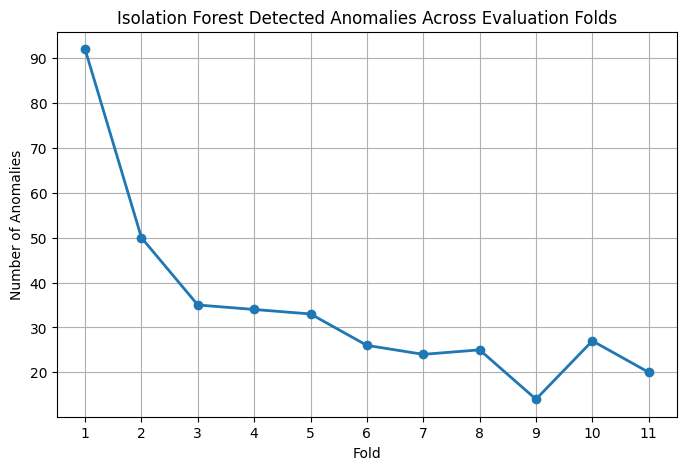

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    fold_summary["Fold"],
    fold_summary["Anomalies"],
    marker="o",
    linewidth=2
)

plt.title("Isolation Forest Detected Anomalies Across Evaluation Folds")
plt.xlabel("Fold")
plt.ylabel("Number of Anomalies")
plt.xticks(fold_summary["Fold"])
plt.grid(True)

plt.show()

### Results

In [15]:
# Prediction results
prediction_results = results[
    [
        # Identification
        "date",
        "company",
        "isin_code",

        # Engineered features (explainability)
        "price_return",
        "intraday_range",
        "distance_to_52wk_high",
        "distance_to_52wk_low",
        "turnover_ratio",
        "relative_volume",
        "bid_discount",
        "ask_premium",
        "relative_spread",

        # Model output
        "anomaly",
        "anomaly_score",

        # Explainability
        "primary_reason",
        "supporting_evidence",
        "investigation_category"
    ]
]

# Merge with original features for analysis
results = prediction_results.merge(results_info, on=["date", "company", "isin_code"], how="left")

# ADD SEVERITY LEVEL
results["severity"] = "Normal"
anomaly_mask = results["anomaly"] == -1
results.loc[anomaly_mask, "severity"] = pd.qcut(results.loc[anomaly_mask, "anomaly_score"],q=[0, 0.33, 0.66, 1],labels=["High", "Medium", "Low"])

# Sort most suspicious first
results = results.sort_values("anomaly_score")

results = results[
    [
        # IDENTIFIERS
        "date",
        "company",
        "isin_code",

        # ORIGINAL MARKET INFORMATION
        "sector",
        "status",
        "previous_price",
        "vwap",
        "volume",
        "total_no_of_shares_issued",
        "mrt_cap",
        
        # ENGINEERED FEATURES
        "price_return",
        "intraday_range",
        "distance_to_52wk_high",
        "distance_to_52wk_low",
        "turnover_ratio",
        "relative_volume",
        "bid_discount",
        "ask_premium",
        "relative_spread",

        # MODEL OUTPUT
        "anomaly",
        "anomaly_score",
        
        # SEVERITY
        "severity",

        # ANOMALY EXPLANATION
        "primary_reason",
        "supporting_evidence",
        "investigation_category",


    ]
]

# View anomalies
display(results.head())

,date,company,isin_code,sector,status,previous_price,vwap,volume,total_no_of_shares_issued,mrt_cap,price_return,intraday_range,distance_to_52wk_high,distance_to_52wk_low,turnover_ratio,relative_volume,bid_discount,ask_premium,relative_spread,anomaly,anomaly_score,severity,primary_reason,supporting_evidence,investigation_category
276,2024-01-09,Sasini Plc Ord 1.00,KE0000000430,AGRICULTURAL,cd,20.00,21.95,"14,900.00","228,055,500.00","5,005,818,225.00",0.10,0.10,0.33,0.22,0.00,10.80,0.09,0.00,0.09,-1,-0.13,High,Multi-factor Trading Anomaly,Trading volume was 10.8 times above its recent average. | Share price increased by 9.7%. | Intraday price range reached 10.0%.,Multi-factor
294,2024-01-09,Bamburi Cement Plc Ord 5.00,KE0000000059,CONSTRUCTION & ALLIED,ord,37.80,35.00,"5,247,600.00","362,959,275.00","12,703,574,625.00",-0.07,0.07,0.19,0.64,0.01,943.81,-0.01,0.06,0.06,-1,-0.13,High,Multi-factor Trading Anomaly,Trading volume was 943.8 times above its recent average. | Share price decreased by 7.4%. | A high proportion of outstanding shares changed hands.,Multi-factor
1372,2024-01-31,Sasini Plc Ord 1.00,KE0000000430,AGRICULTURAL,cd,21.00,21.00,"1,506,000.00","228,055,500.00","4,789,165,500.00",0.00,0.00,0.36,0.17,0.01,515.75,0.00,0.05,0.05,-1,-0.13,High,Abnormal Trading Volume,Trading volume was 515.8 times above its recent average. | A high proportion of outstanding shares changed hands.,Trading Activity
428,2024-01-11,Umeme Ltd Ord 0.50,UG0000001145,ENERGY & PETROLEUM,cd,16.00,15.15,"54,700.00","1,623,878,005.00","24,601,751,776.00",-0.05,0.12,0.16,1.40,0.00,7.12,0.04,0.07,0.12,-1,-0.12,High,Liquidity Deterioration,"Intraday price range reached 11.6%. | Bid-ask spread widened, indicating reduced liquidity.",Liquidity
54,2024-01-03,Umeme Ltd Ord 0.50,UG0000001145,ENERGY & PETROLEUM,cd,15.55,14.40,"3,300.00","1,623,878,005.00","23,383,843,272.00",-0.07,0.09,0.20,1.29,0.00,1.59,-0.06,0.11,0.05,-1,-0.12,High,Large Price Movement,Share price decreased by 7.4%.,Price Behaviour


In [16]:
# DAILY ANOMALY RATE
daily_anomaly_rate = (results.groupby("date")["anomaly"].apply(lambda x: (x == -1).mean()).reset_index(name="anomaly_rate"))
display(daily_anomaly_rate)

,date,anomaly_rate
0,2024-01-03,0.26
1,2024-01-04,0.27
2,2024-01-05,0.21
3,2024-01-08,0.33
4,2024-01-09,0.32
5,2024-01-10,0.14
6,2024-01-11,0.18
7,2024-01-12,0.14
8,2024-01-15,0.15
9,2024-01-16,0.15


In [17]:
# Sample output
sample_result = results[results["date"] == "2024-03-19"].reset_index(drop = True)
sample_result.head(10)

,date,company,isin_code,sector,status,previous_price,vwap,volume,total_no_of_shares_issued,mrt_cap,price_return,intraday_range,distance_to_52wk_high,distance_to_52wk_low,turnover_ratio,relative_volume,bid_discount,ask_premium,relative_spread,anomaly,anomaly_score,severity,primary_reason,supporting_evidence,investigation_category
0,2024-03-19,British American Tobacco Kenya Plc Ord 10.00,KE0000000075,MANUFACTURING & ALLIED,cd,415.00,410.00,"128,500.00","100,000,000.00","41,000,000,000.00",-0.01,0.01,0.17,0.03,0.00,36.93,0.00,0.00,0.00,-1,-0.04,High,Abnormal Trading Volume,Trading volume was 36.9 times above its recent average. | A high proportion of outstanding shares changed hands.,Trading Activity
1,2024-03-19,Safaricom Plc Ord 0.05,KE1000001402,TELECOMMUNICATION,xd,14.60,14.80,"3,772,800.00","40,065,428,000.00","592,968,334,400.00",0.01,0.03,0.41,0.29,0.00,0.16,0.00,0.01,0.01,-1,-0.03,Medium,Unusual Market Behaviour Pattern,"Price return within normal range, Trading volume within normal range and bid-ask spread within normal range.\n The combined behavior of these indicators differs from historical observations.",Model Detected Pattern
2,2024-03-19,Sasini Plc Ord 1.00,KE0000000430,AGRICULTURAL,xd,19.70,20.55,"1,200.00","228,055,500.00","4,686,540,525.00",0.04,0.02,0.37,0.14,0.00,0.59,0.04,0.02,0.06,-1,-0.03,Medium,Unusual Market Behaviour Pattern,"Price return within normal range, Trading volume within normal range and bid-ask spread within normal range.\n The combined behavior of these indicators differs from historical observations.",Model Detected Pattern
3,2024-03-19,Stanbic Holdings Plc ord.5.00,KE0000000091,BANKING,cd,119.50,124.25,"4,200.00","395,321,638.00","49,118,713,522.00",0.04,0.03,0.06,0.38,0.00,0.71,0.04,0.01,0.05,-1,-0.01,Low,Unusual Market Behaviour Pattern,"Price return within normal range, Trading volume within normal range and bid-ask spread within normal range.\n The combined behavior of these indicators differs from historical observations.",Model Detected Pattern
4,2024-03-19,ABSA Bank Kenya Plc Ord 0.50,KE0000000067,BANKING,cd,13.75,14.00,"1,643,500.00","5,431,536,000.00","76,041,504,000.00",0.02,0.03,0.02,0.40,0.00,4.44,0.01,0.00,0.01,-1,-0.00,Low,High Market Activity,A high proportion of outstanding shares changed hands.,Trading Activity
5,2024-03-19,Standard Chartered Bank Kenya Ltd Ord 5.00,KE0000000448,BANKING,cd,185.75,185.50,"31,600.00","377,861,629.00","70,093,332,180.00",-0.00,0.01,0.01,0.38,0.00,0.94,0.00,0.00,0.00,1,0.01,Normal,None,None,None
6,2024-03-19,ARM Cement Plc Ord 1.00,KE0000000034,CONSTRUCTION & ALLIED,S,5.55,5.55,0.00,"959,940,200.00","5,327,668,110.00",0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1,0.01,Normal,None,None,None
7,2024-03-19,East African Breweries Plc Ord 2.00,KE0000000216,MANUFACTURING & ALLIED,xd,119.25,120.50,"6,300.00","790,774,356.00","95,288,309,898.00",0.01,0.01,0.37,0.20,0.00,0.04,0.01,-0.00,0.00,1,0.01,Normal,None,None,None
8,2024-03-19,Mumias Sugar Co. Ltd Ord 2.00,KE0000000372,MANUFACTURING & ALLIED,S,0.27,0.27,0.00,"1,530,000,000.00","413,100,000.00",0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1,0.03,Normal,None,None,None
9,2024-03-19,Deacons (East Africa) Plc Ord 2.50AIMS,KE5000005438,COMMERCIAL AND SERVICES,S,0.45,0.45,0.00,"123,558,228.00","55,601,203.00",0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1,0.03,Normal,None,None,None


In [18]:
# save
sample_result.to_csv("results_2024_03_19.csv",index=False)